In [1]:
import pandas as pd

In [9]:
df_aldi = pd.read_csv('All_Data_Aldi.csv', usecols=['supermarket', 'prices_(£)', 'category', 'date', 'own_brand'])
print(df_aldi.shape)
print(df_aldi.head())
print(df_aldi['date'].unique())
print(df_aldi['category'].unique())

(464863, 5)
  supermarket  prices_(£)      date       category  own_brand
0        Aldi        3.09  20240413  baby_products      False
1        Aldi        3.09  20240413  baby_products      False
2        Aldi        3.59  20240413  baby_products      False
3        Aldi        4.79  20240413  baby_products      False
4        Aldi        4.79  20240413  baby_products      False
[20240413 20240412 20240411 20240410 20240409 20240408 20240407 20240406
 20240405 20240404 20240403 20240402 20240401 20240331 20240330 20240329
 20240328 20240327 20240326 20240325 20240324 20240322 20240321 20240320
 20240319 20240318 20240317 20240316 20240315 20240313 20240312 20240311
 20240310 20240309 20240308 20240307 20240306 20240305 20240304 20240303
 20240302 20240301 20240229 20240228 20240227 20240226 20240225 20240224
 20240223 20240222 20240221 20240220 20240219 20240218 20240217 20240216
 20240215 20240214 20240213 20240212 20240211 20240210 20240209 20240208
 20240207 20240206 20240205 2024

In [20]:
#read all supermarket's data
supermarkets = ['Aldi', 'Asda', 'Morrisons', 'Sains', 'Tesco']
files = {'Aldi': 'All_Data_Aldi.csv',
         'Asda': 'All_Data_Asda.csv',
         'Morrisons': 'All_Data_Morrisons.csv',
         'Sainsbury': 'All_Data_Sains.csv',
         'Tesco': 'All_Data_Tesco.csv'}
dfs = []
for name, file in files.items():
    df = pd.read_csv(file, usecols=['prices_(£)', 'category', 'date'])
    df['supermarket'] = name
    dfs.append(df)

df_all = pd.concat(dfs, ignore_index= True)

#convert the format of date
df_all['date'] = pd.to_datetime(df_all['date'], format='%Y%m%d')

print(df_all.shape)
print(df_all['supermarket'].value_counts())

(9529242, 4)
supermarket
Sainsbury    2600289
Asda         2456414
Tesco        2213611
Morrisons    1794065
Aldi          464863
Name: count, dtype: int64


## Data loading

- Combined dataset: 9,529,242 rows across 5 supermarkets
- Data range: 9 January 2024 to 13 April 2024 (3 months)
- 10 product categories: baby_products, food_cupbroad, health_products, pets, househeld, frozen, fresh_food, drinks, bakery, free-from

**Notable observation:** Aldi has significantly fewer product listings '464,863' compared to other supermarkets (1.8 million - 2.6 million), Aldi's business model of maintaining a limited SKU(stock keep unit) range to achieve operational efficiency and relatively cheaper product prices.

In [21]:
# Calculate average price for supermarkets
avg_price = df_all.groupby('supermarket')['prices_(£)'].mean().sort_values()
print('Average price by supermarket:')
print(avg_price.round(2))

#Calculate average price of each categories for supermarkets
category_price = df_all.groupby(['supermarket', 'category'])['prices_(£)'].mean().round(2)
print('\nAverage price by supermarket and category:')
print(category_price.unstack())

Average price by supermarket:
supermarket
Aldi         2.22
Morrisons    4.89
Tesco        5.28
Sainsbury    5.46
Asda         5.76
Name: prices_(£), dtype: float64

Average price by supermarket and category:
category     baby_products  bakery  drinks  food_cupboard  free-from  \
supermarket                                                            
Aldi                  2.02    1.28    4.45           1.26       3.00   
Asda                  5.61    3.26    6.84           2.14       2.68   
Morrisons             4.78    2.45    8.64           2.27       2.31   
Sainsbury             4.76    2.29    8.01           2.30       3.51   
Tesco                 5.40    2.75    7.39           2.17        NaN   

category     fresh_food  frozen  health_products   home  household  pets  
supermarket                                                               
Aldi               2.31    2.23             1.84    NaN       2.01  2.16  
Asda               3.02    2.94             7.15  12.40      

In [22]:
# Check what categories are in Tesco
tesco_categories = df_all[df_all['supermarket'] == 'Tesco']['category'].unique()
print('Tesco categories:', tesco_categories)

# Check what categories are in Aldi
aldi_categories = df_all[df_all['supermarket'] == 'Aldi']['category'].unique()
print('Aldi categories:', aldi_categories)

Tesco categories: <StringArray>
[      'household', 'health_products',   'baby_products',          'drinks',
            'home',   'food_cupboard',          'frozen',            'pets',
      'fresh_food',          'bakery']
Length: 10, dtype: str
Aldi categories: <StringArray>
[  'baby_products',   'food_cupboard', 'health_products',            'pets',
       'household',          'frozen',      'fresh_food',          'drinks',
          'bakery',       'free-from']
Length: 10, dtype: str


**Data Quality Note:** Category labels are inconsistent across supermarkets. Tesco has a 'home' category that absent from Aldi, while Aldi has 'free-from' that absent from Tesco. This suggests the dataset was not a standardised taxonomy and might scraped by using each supermarket's own website categorisation. Therefore, analysis will use only categories present across all 5 supermarkets to ensure a fair comparison.

In [23]:
# keep categories that all the supermarkets have as valid categories
category_price_df = category_price.unstack()

# find prices of valid categories
valid_categories = category_price_df.dropna(axis=1).columns
print('Categories available in all supermarkets:')
print(valid_categories)

# calculate a fair average price by using valid categories
df_filtered = df_all[df_all['category'].isin(valid_categories)]
avg_price_fair = df_filtered.groupby('supermarket')['prices_(£)'].mean().sort_values()
print('\nFair comparison - average price:')
print(avg_price_fair.round(2))

Categories available in all supermarkets:
Index(['baby_products', 'bakery', 'drinks', 'food_cupboard', 'fresh_food',
       'frozen', 'health_products', 'household', 'pets'],
      dtype='str', name='category')

Fair comparison - average price:
supermarket
Aldi         2.21
Morrisons    4.43
Tesco        4.45
Asda         4.65
Sainsbury    5.00
Name: prices_(£), dtype: float64


## Price Comparison (Fair - 8 shared categories)
Shared categories: baby_products, bakery, drinks, food_cupboard, fresh_food, frozen, health_products, househeld, pets
- Aldi          2.21 (cheapest)
- Morrisons     4.43
- Tesco         4.45
- Asda          4.65
- Sainsburry    5.00 (most expensive)

**Key finding:** Even on a like-for-like basis, Aldi is approximately 50% cheaper than traditional supermarkets. This price gap helps explain the consumer shift toward discounters like Aldi during the 2021-2023 inflation surge.

In [24]:
import matplotlib.pyplot as plt

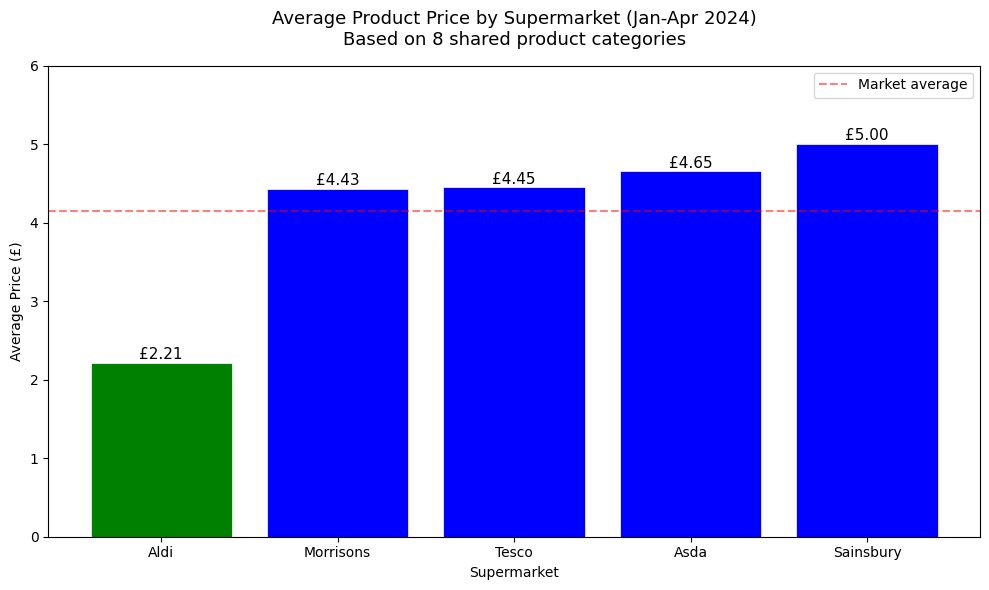

In [25]:
fig, ax = plt.subplots(figsize=(10, 6))
colors = ['green' if s=='Aldi' else 'blue' for s in avg_price_fair.index]
bars = ax.bar(avg_price_fair.index, avg_price_fair.values, color=colors, edgecolor='white', linewidth=0.5)

for bar, val in zip(bars, avg_price_fair.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05, f'£{val:.2f}', ha='center', fontsize=11)
ax.set_title('Average Product Price by Supermarket (Jan-Apr 2024)\n'
                'Based on 8 shared product categories', fontsize=13, pad=15)
ax.set_xlabel('Supermarket')
ax.set_ylabel('Average Price (£)')
ax.set_ylim(0,6)
ax.axhline(y=avg_price_fair.mean(), color='red', linestyle='--', alpha=0.5, label='Market average')
ax.legend()

plt.tight_layout()
plt.savefig('price_comparison.png', dpi=150)
plt.show()

In [26]:
import numpy as np

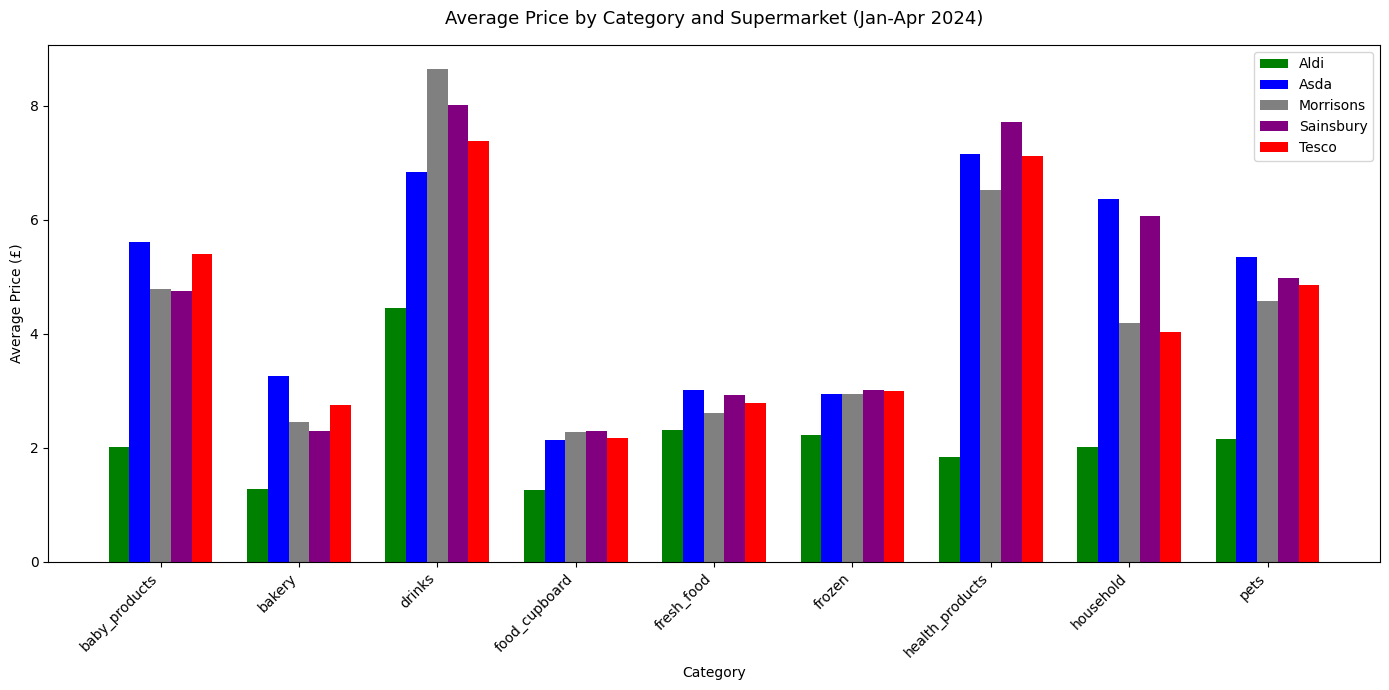

In [30]:
# calculate category average price for each supermarket
cat_price = df_filtered.groupby(['category', 'supermarket'])['prices_(£)'].mean().round(2)
cat_price_df = cat_price.unstack()

# diagram
fig, ax = plt.subplots(figsize=(14, 7))

x = np.arange(len(cat_price_df.index))
width = 0.15
supermarkets = cat_price_df.columns
colors_map = {'Aldi': 'green',
             'Asda': 'blue',
             'Morrison': 'orange',
             'Sainsbury': 'purple',
             'Tesco': 'red'}

for i, s in enumerate(supermarkets):
    ax.bar(x + i*width, cat_price_df[s],
          width=width, label=s, color=colors_map.get(s, 'grey'))

ax.set_title('Average Price by Category and Supermarket (Jan-Apr 2024)',
            fontsize=13, pad=15)
ax.set_xlabel('Category')
ax.set_ylabel('Average Price (£)')
ax.set_xticks(x + width*2)
ax.set_xticklabels(cat_price_df.index, rotation=45, ha='right')
ax.legend()

plt.tight_layout()
plt.savefig('category_price_comparison.png', dpi=150)
plt.show()

## Price Comparison by Category
Aldi's price advantage is not uniform across categories:

**Largest price gaps (Aldi significantly cheaper):**
- Drinks: Aldi is round £4 vs others £7-£9
- Baby products: Aldi is round £2 vs others £4-£6
- Health products: Aldi is round £2 vs others £6.5-£7.5
- Househeld: Aldi is round £2 vs others £4-£6

**Possible reasons:**
- Traditional supermarkets usually stock a high percentage of national A-brands (e.g. Coca-Cola, Red-bull, Fairy, Felix, Pedigree) which carry premium brand and marketing costs whereas Aldi primarily sells its own private-label equivalents (e.g. Vive cola, Mamia), this cuts the retail price significantly as shown.
- Aldi stocks far fewer variations per category, allowing them to buy massive quantities of a single item and secure maximum wholesale discounts.
- For products have a long shelf life and low transport risks like cleaning products, Aldi can ship these in ready-to-display cardboard boxes, so stuff just drop the whole pallet onto the floor which can reduce shelf-stacking labor costs.

**Smallest price gaps:**
- Bakery, food cupboard, fresh food and frozen show more competitive pricing across all supermarkets.

**Possible reasons:**
- Essentials like bread, rice, pasta, fruit, vegs, milk and meat, where customers are highly price-sensitive. So traditional supermarkets usually to actively match 'Aldi price' to avoid losing customers.
- Frozen and fresh food categories require continuous cold-chain logistics and have a higher waste rate. These baseline operational costs are relatively fixed, leaving Aldi with less room to reduce costs and prices.

In [33]:
# read data of market share
df_market = pd.read_csv('uk_supermarket_data.csv')

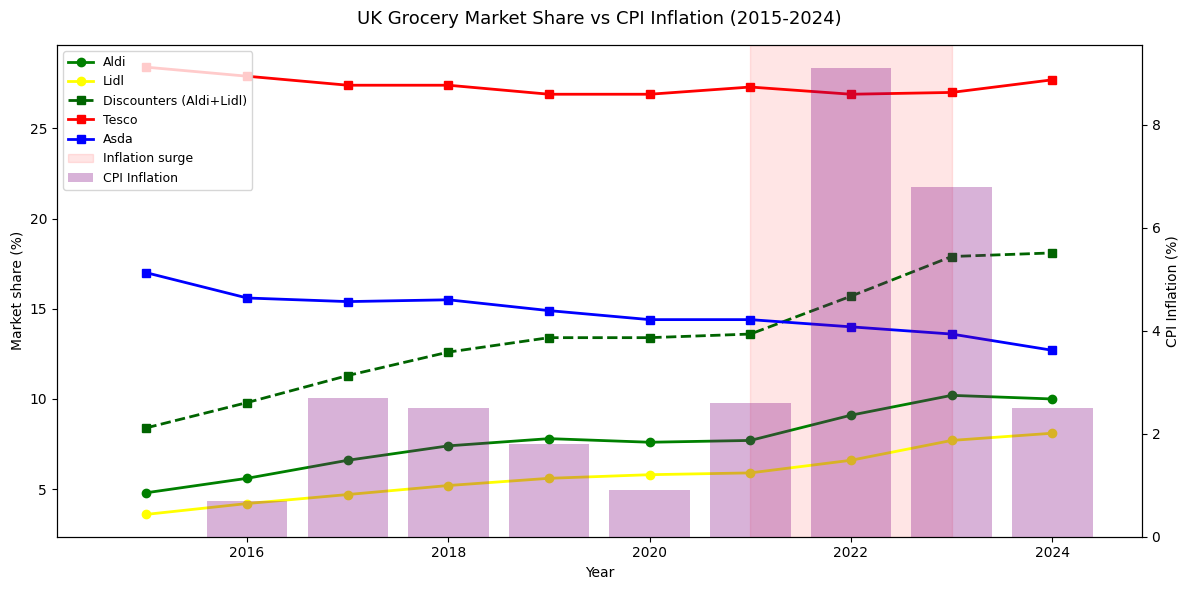

In [37]:
fig, ax1 = plt.subplots(figsize=(12, 6))

# discounters's market share diagram
ax1.plot(df_market['Year'], df_market['Aldi'], color='green', marker='o', linewidth=2, label='Aldi')
ax1.plot(df_market['Year'], df_market['Lidl'], color='yellow', marker='o', linewidth=2, label='Lidl')
ax1.plot(df_market['Year'], df_market['Discounters'], color='darkgreen', marker='s', linewidth=2, linestyle='--',
         label='Discounters (Aldi+Lidl)')

# traditional supermarkets's market share diagram
ax1.plot(df_market['Year'], df_market['Tesco'], color='red', marker='s', linewidth=2, label='Tesco')
ax1.plot(df_market['Year'], df_market['Asda'], color='blue', marker='s', linewidth=2, label='Asda')
ax1.set_xlabel('Year')
ax1.set_ylabel('Market share (%)')

# CPI diagram
ax2 = ax1.twinx()
ax2.bar(df_market['Year'], df_market['CPI_Annual_Avg'], alpha=0.3, color='purple', label='CPI Inflation')
ax2.set_ylabel('CPI Inflation (%)')

# label inflation peak
ax1.axvspan(2021, 2023, alpha=0.1, color='red', label='Inflation surge')

# legend combination
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1+lines2, labels1+labels2, loc='upper left', fontsize=9)

ax1.set_title('UK Grocery Market Share vs CPI Inflation (2015-2024)', fontsize=13, pad=15)
plt.tight_layout()
plt.savefig('market_share_trend.png', dpi=150)
plt.show()

## Market Share Trends vs CPI Inflation (2015-2024)
**Key observation:**
1. Discounters (Aldi&Lidl) grew consistently from 8.4% (4.8% + 3.6%) in 2015 to 18.1% (10.0% + 8.1%) in 2024 - more than doubling their combined market share over the dacade.
2. Growth accelerated visibly during the 2021-2023 inflation surge (CPI averaged 9.1% in 2022, peaking at 11.1% in October 2022), suggesting inflation acted as a catalyst rather than the sole driver of the shift.
3. Asda experienced the sharpest decline among traditional supermarkets, falling from approximately 17% in 2015 to 13% in 2024, suggesting it might lost customers to discounters.
4. Tesco remained relatively stable around 27%, however it has slightly droped to 26.9% in 2022 from 27.3% in 2021 for temporary, then came back to 27.0% in 2023. This indicating that its scale and price-matching strategy provided some protection against discounter growth.

**Is the consumer shift toward discounters represents a temporary response to inflation or a permanent change in behaviour?**

The data suggests: despite CPI falling back to 2.5% in 2024, discounter's combined market share continued to rise slightlt (17.9% in 2023 to 18.1% in 2024), rather than reverting to pre-inflation levels.
This is probably because of 'ratchet effect' - once consumers discover the quality and value of discounters during a period of financial pressure, many do not revert to their previous shopping habits even after the pressure. The 2020 period when inflation fell to just 0.9%, the lowest in the dataset further supports this: discounter growth continued uninterrupted even at near-zero inflaion, suggesting that the structural shift is driven by long-term behavioural change rather than price pressure alone.

**Note on supermarket selection:** Morrisons and Sainsbury's are excluded from the chart for visual clarity, and both follow a similar pattern to Asda. Tesco is included as the market leader, and Asda as the supermarket with the steepest decline.

## Conclusion

### Overview
This analysis examined the price competitiveness among major UK supermarkets and determine whether the consumer shift toward discounters is a temporary response to inflation or a permanent behavioural change.

### Key Findings
1. Aldi's average price (£2.21) is approximately 50% lower than traditional supermarkets (£4.43-£5.00) on a like-for-like basis across 8 shared product categories. The price gap is largest in drinks, baby products, and health products - where Aldi's private-label strategy delivers the greatest savings.
2. Discounter's combined market share more than doubled from 8.3% in 2015 to 18.1% in 2024. Growth accelerated visibly during the 2021-2023 inflation surge (CPI averaged 9.1% in 2022, peaking at 11.1% in October 2022), suggesting inflation acted as a catalyst rather than the sole driver.
3. The consumer shift appears permanent: despite CPI returning to2.5% in 2024, discounter's market share continued to rise, consistent with a ratchet effect where consumers who discover discounters during financial pressure do not revert to previous habits.

### Limitations
- Price data only covered January-April 2024 and cannot capture price changes over time.
- Market share data is annual and may obscure seasonal variation.
- Analysis does not account for Aldi/Lidl store expansion, which also contributed to market share growth.
- Product categories are not perfectly standardised across supermarkets, which may affect price comparisons.
